# EDA — OECD How's Life? Well-being Database (Current Well-being extract)

Long-format SDMX export: one row per (country, measure, year) observation.
Coverage: 47 countries, 21 measures across 10 well-being domains, 2010–2026.

Sections:
1. Load & clean
2. Structural overview (coverage, missingness)
3. Per-measure distributions
4. Time trends
5. Latest-year cross-country comparison
6. Wide pivot + correlation between measures
7. Australia deep-dive vs OECD

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

CSV_PATH = "OECD Data.csv"  # adjust if needed

## 1. Load & clean

In [5]:
raw = pd.read_csv(CSV_PATH)
print(raw.shape)
raw.head(3)

(8806, 30)


,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,REF_AREA,Reference area,MEASURE,Measure,UNIT_MEASURE,Unit of measure,AGE,Age,SEX,Sex,EDUCATION_LEV,Education level,DOMAIN,Domain,TIME_PERIOD,Time period,OBS_VALUE,Observation value,OBS_STATUS,Observation status,UNIT_MULT,Unit multiplier,DECIMALS,Decimals,BASE_PER,Base period
0,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUS,Australia,1_1,Households and NPISHs net adjusted disposable ...,USD_PPP_PS,"US dollars per person, PPP converted",_T,Total,_T,Total,_T,Total,HSL_1,Income and wealth,2010,NaN,44625.0,NaN,A,Normal value,0,Units,2,Two,2023,NaN
1,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUS,Australia,1_1,Households and NPISHs net adjusted disposable ...,USD_PPP_PS,"US dollars per person, PPP converted",_T,Total,_T,Total,_T,Total,HSL_1,Income and wealth,2011,NaN,45369.0,NaN,A,Normal value,0,Units,2,Two,2023,NaN
2,DATAFLOW,OECD.WISE.WDP:DSD_HSL@DF_HSL_CWB(1.1),Current well-being,I,AUS,Australia,1_1,Households and NPISHs net adjusted disposable ...,USD_PPP_PS,"US dollars per person, PPP converted",_T,Total,_T,Total,_T,Total,HSL_1,Income and wealth,2012,NaN,44830.0,NaN,A,Normal value,0,Units,2,Two,2023,NaN


In [6]:
# The export duplicates every dimension as CODE + human-readable label,
# plus constant structural columns. Keep only what's analytically useful.
raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 8806 entries, 0 to 8805
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   STRUCTURE           8806 non-null   str    
 1   STRUCTURE_ID        8806 non-null   str    
 2   STRUCTURE_NAME      8806 non-null   str    
 3   ACTION              8806 non-null   str    
 4   REF_AREA            8806 non-null   str    
 5   Reference area      8806 non-null   str    
 6   MEASURE             8806 non-null   str    
 7   Measure             8806 non-null   str    
 8   UNIT_MEASURE        8806 non-null   str    
 9   Unit of measure     8806 non-null   str    
 10  AGE                 8806 non-null   str    
 11  Age                 8806 non-null   str    
 12  SEX                 8806 non-null   str    
 13  Sex                 8806 non-null   str    
 14  EDUCATION_LEV       8806 non-null   str    
 15  Education level     8806 non-null   str    
 16  DOMAIN           

In [7]:
# Columns that are entirely null or constant carry no information
null_cols = raw.columns[raw.isna().all()].tolist()
const_cols = [c for c in raw.columns if raw[c].nunique(dropna=False) == 1]
print("All-null columns:", null_cols)
print("Constant columns:", const_cols)

All-null columns: ['Time period', 'Observation value', 'Base period']
Constant columns: ['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'AGE', 'Age', 'SEX', 'Sex', 'EDUCATION_LEV', 'Education level', 'Time period', 'Observation value', 'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'Decimals', 'Base period']


In [8]:
df = raw.rename(columns={
    "Reference area": "country",
    "REF_AREA": "iso3",
    "Measure": "measure",
    "MEASURE": "measure_code",
    "Domain": "domain",
    "Unit of measure": "unit",
    "TIME_PERIOD": "year",
    "OBS_VALUE": "value",
    "Observation status": "obs_status",
})[["iso3", "country", "domain", "measure_code", "measure", "unit",
    "year", "value", "obs_status"]].copy()

df["year"] = df["year"].astype(int)
print(df.shape)
df.head()

(8806, 9)


,iso3,country,domain,measure_code,measure,unit,year,value,obs_status
0,AUS,Australia,Income and wealth,1_1,Households and NPISHs net adjusted disposable ...,"US dollars per person, PPP converted",2010,44625.0,Normal value
1,AUS,Australia,Income and wealth,1_1,Households and NPISHs net adjusted disposable ...,"US dollars per person, PPP converted",2011,45369.0,Normal value
2,AUS,Australia,Income and wealth,1_1,Households and NPISHs net adjusted disposable ...,"US dollars per person, PPP converted",2012,44830.0,Normal value
3,AUS,Australia,Income and wealth,1_1,Households and NPISHs net adjusted disposable ...,"US dollars per person, PPP converted",2013,45377.0,Normal value
4,AUS,Australia,Income and wealth,1_1,Households and NPISHs net adjusted disposable ...,"US dollars per person, PPP converted",2014,46031.0,Normal value


In [30]:
print(df["measure"].unique())
print(df["domain"].unique())
print(df["unit"].unique())

<ArrowStringArray>
['Households and NPISHs net adjusted disposable income per capita',                                               'Median net wealth',
                     'Households living in overcrowded conditions',                                           'Housing affordability',
                                      'Student mathematics skills',                               'Time spent in social interactions',
                                  'Not having a say in government',                                                        'Time off',
                                     'Gender gap in working hours',                                                   'Voter turnout',
                                               'Life satisfaction',                'Top average household disposable income quintile',
                                        'Life expectancy at birth',                             'Deaths from suicide, alcohol, drugs',
                                 'Ex

In [9]:
# Sanity checks
assert df["value"].notna().all(), "unexpected missing OBS_VALUE"
dupes = df.duplicated(subset=["iso3", "measure_code", "year"]).sum()
print("Duplicate (country, measure, year) rows:", dupes)
if dupes:
    display(df[df.duplicated(subset=["iso3", "measure_code", "year"], keep=False)]
            .sort_values(["iso3", "measure_code", "year"]).head(20))

Duplicate (country, measure, year) rows: 0


## 2. Structural overview

In [10]:
print("Countries:", df["country"].nunique())
print("Measures :", df["measure"].nunique())
print("Domains  :", df["domain"].nunique())
print("Years    :", df["year"].min(), "-", df["year"].max())
print()
print(df["obs_status"].value_counts())

Countries: 47
Measures : 21
Domains  : 10
Years    : 2010 - 2026

obs_status
Normal value          8540
Estimated value         92
Provisional value       89
Definition differs      45
Time series break       40
Name: count, dtype: int64


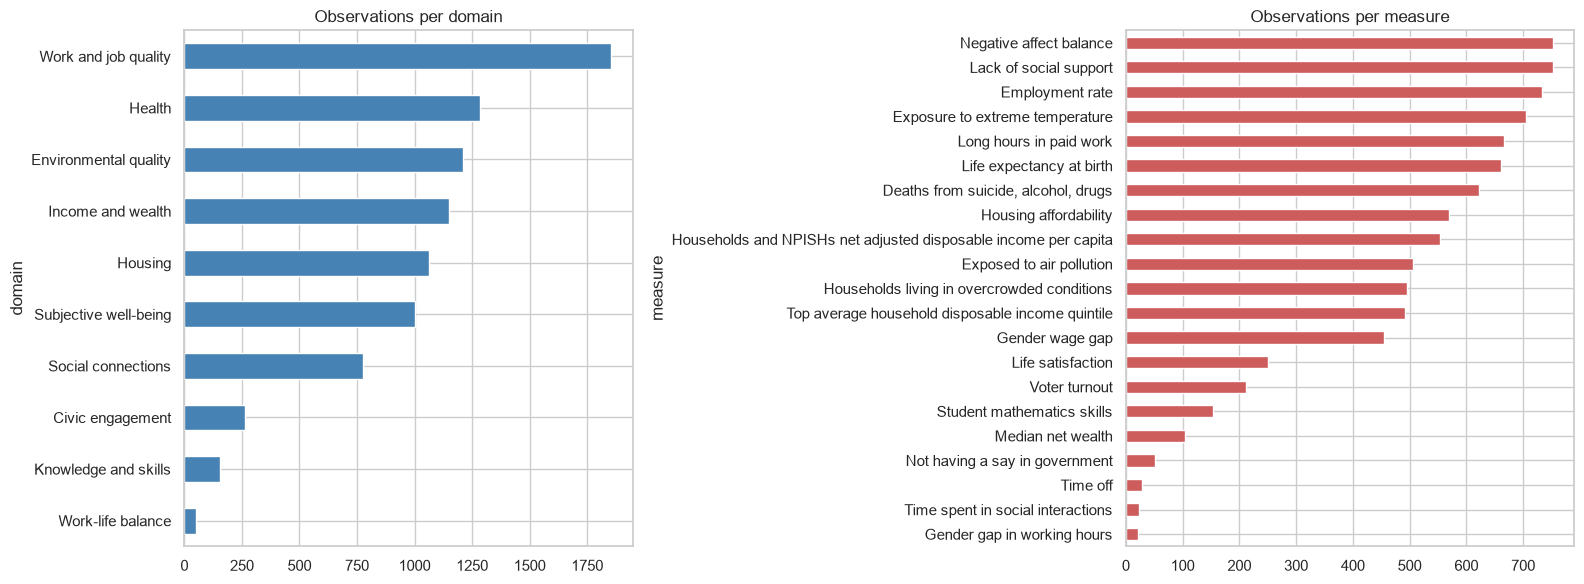

In [11]:
# Rows per domain / measure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df["domain"].value_counts().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Observations per domain")
axes[0].invert_yaxis()

df["measure"].value_counts().plot.barh(ax=axes[1], color="indianred")
axes[1].set_title("Observations per measure")
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

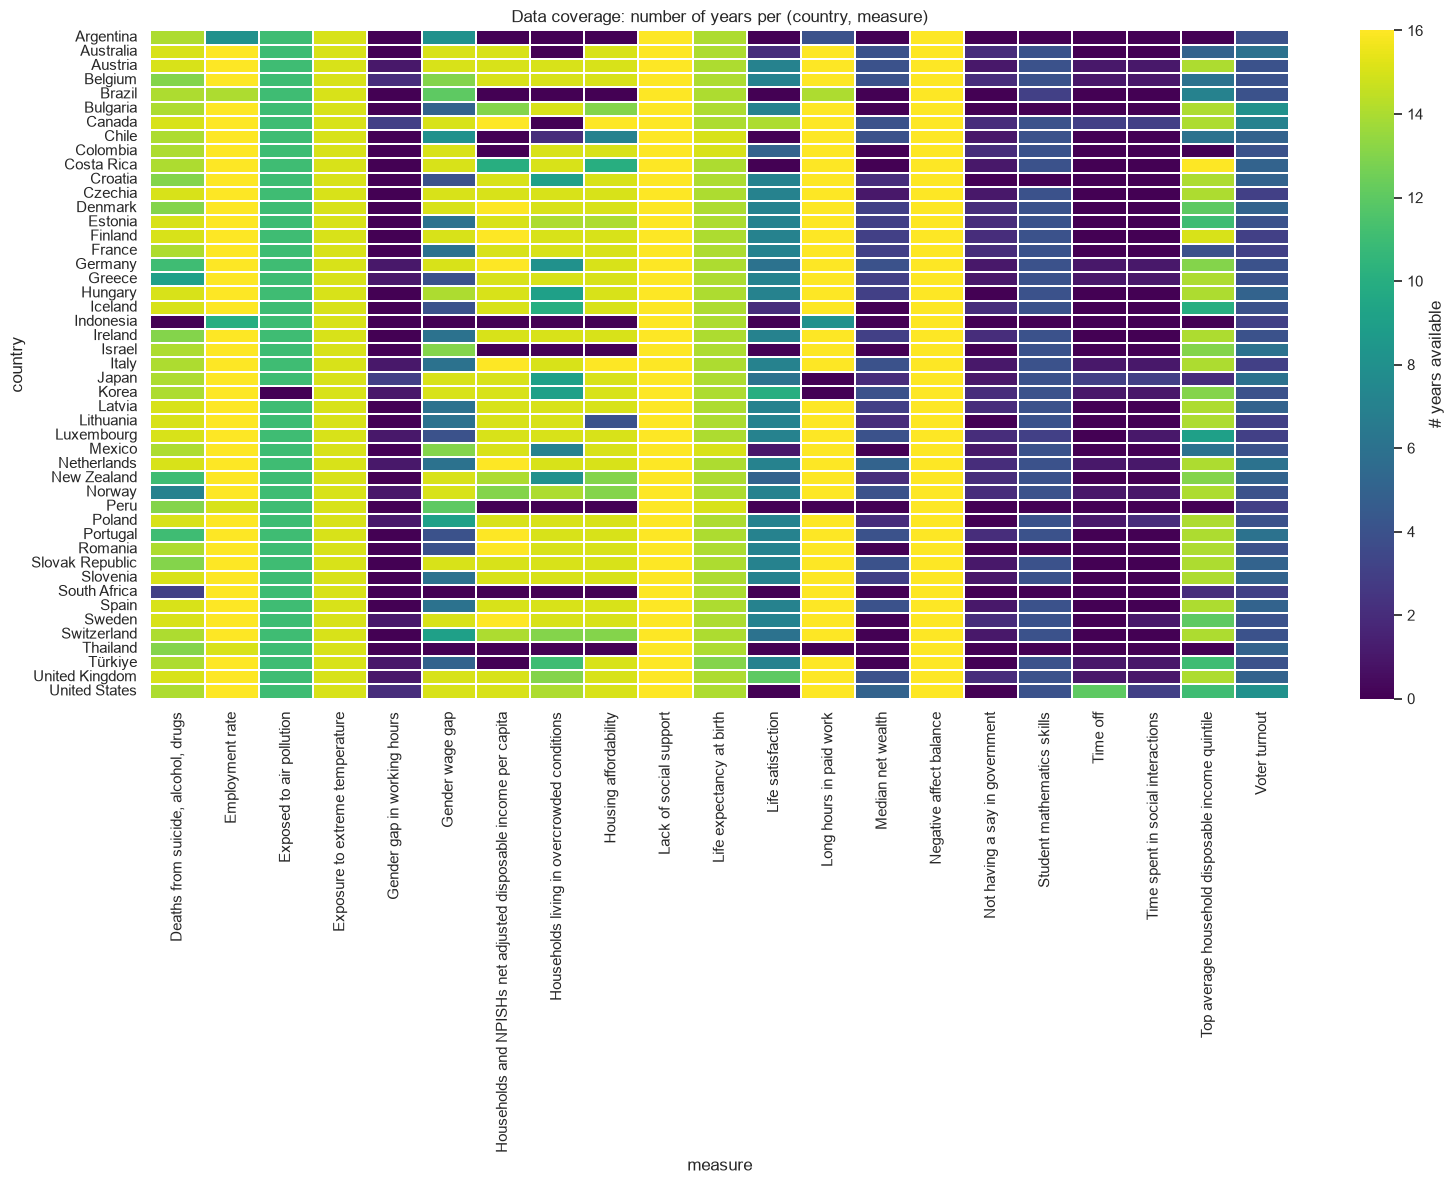

In [12]:
# Coverage matrix: which country x measure combos exist at all?
cov = df.pivot_table(index="country", columns="measure", values="year",
                     aggfunc="count").fillna(0)

plt.figure(figsize=(16, 12))
sns.heatmap(cov, cmap="viridis", cbar_kws={"label": "# years available"},
            linewidths=0.3, linecolor="white")
plt.title("Data coverage: number of years per (country, measure)")
plt.tight_layout()
plt.show()

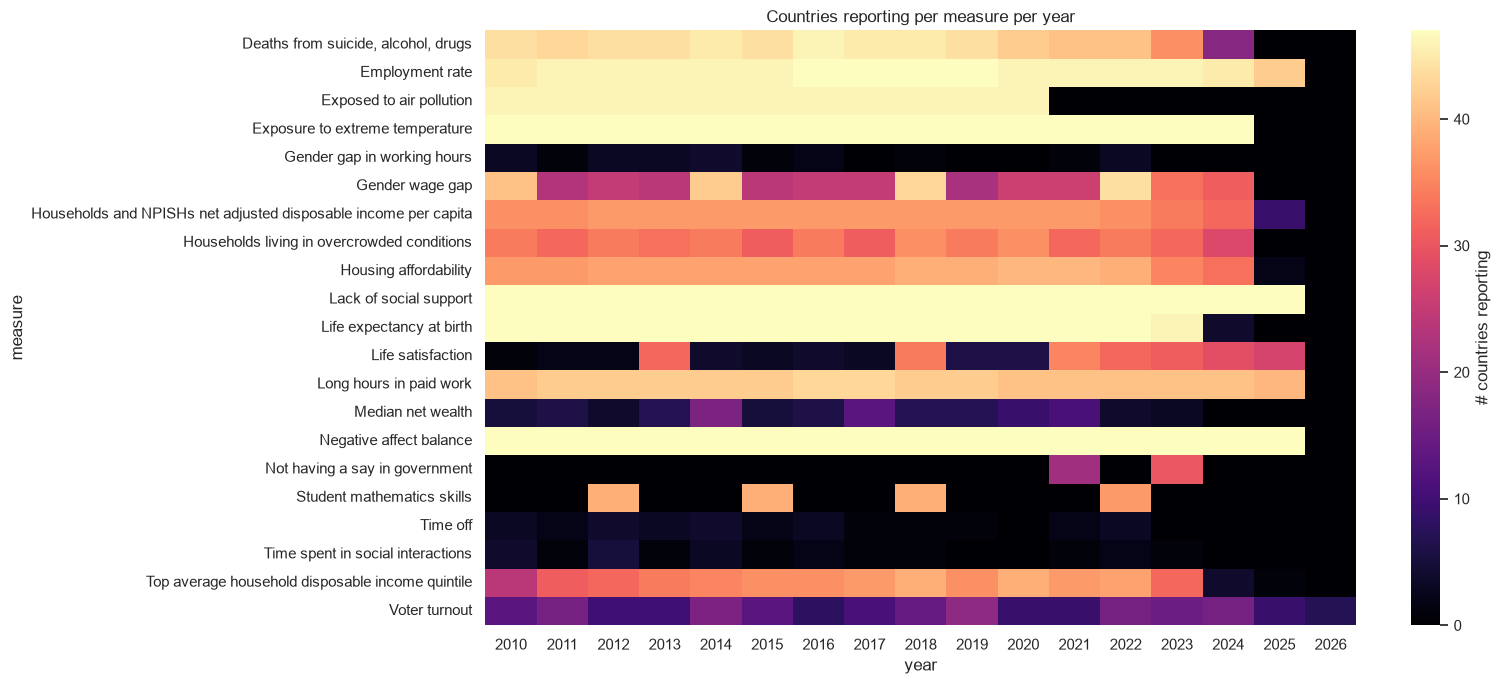

In [13]:
# Coverage by year — is the panel balanced over time?
yr_cov = df.pivot_table(index="year", columns="measure", values="country",
                        aggfunc="nunique").fillna(0).astype(int)
plt.figure(figsize=(16, 7))
sns.heatmap(yr_cov.T, cmap="magma", annot=False,
            cbar_kws={"label": "# countries reporting"})
plt.title("Countries reporting per measure per year")
plt.tight_layout()
plt.show()

# Note: 2024-2026 coverage thins out heavily for most survey-based measures.

## 3. Per-measure distributions

Measures have wildly different units (USD, %, years, deaths/100k, 0-10 scores) — never pool them raw.

In [14]:
summary = (df.groupby(["domain", "measure", "unit"])["value"]
             .agg(["count", "mean", "std", "min", "median", "max"])
             .round(2)
             .sort_values("count", ascending=False))
summary

count       mean        std  \
domain                measure                                            unit                                                                              
Social connections    Lack of social support                             Percentage of population aged 15 years or over        752      10.14       4.99   
Subjective well-being Negative affect balance                            Percentage of population aged 15 years or over        752      13.72       5.11   
Work and job quality  Employment rate                                    Percentage of population aged 25-64 years             734      74.59       7.25   
Environmental quality Exposure to extreme temperature                    Percentage of population                              705       7.55      14.94   
Work and job quality  Long hours in paid work                            Percentage of employees                               666       8.11       8.14   
Health                Life expectancy at birth                           Years                                                 661      79.03       4.07   
                      Deaths from suicide, alcohol, drugs                Deaths per 100 000 inhabitants                        622      22.33      11.66   
Housing               Housing affordability                              Percentage of household gross adjusted disposab...    569      78.81       3.10   
Income and wealth     Households and NPISHs net adjusted disposable i... US dollars per person, PPP converted                  553   37791.01   10866.15   
Environmental quality Exposed to air pollution                           Percentage of population                              506      97.79       6.36   
Housing               Households living in overcrowded conditions        Percentage of households                              495      13.83      10.97   
Income and wealth     Top average household disposable income quintile   Factor of lowest income quintile                      491       5.79       2.79   
Work and job quality  Gender wage gap                                    Percentage of wages of men in the same decile         454      12.96       7.14   
Subjective well-being Life satisfaction                                  0-10 scale                                            251       7.22       0.68   
Civic engagement      Voter turnout                                      Percentage of votes                                   212      68.57      12.64   
Knowledge and skills  Student mathematics skills                         Points                                                154     481.22      37.22   
Income and wealth     Median net wealth                                  US dollars per household, PPP converted               104  209038.16  137583.29   
Civic engagement      Not having a say in government                     Percentage of population aged 16-65 years              51      51.86      12.11   
Work-life balance     Time off                                           Hours per day                                          29      14.78       0.56   
Social connections    Time spent in social interactions                  Hours per week                                         23       5.50       1.94   
Work-life balance     Gender gap in working hours                        Minutes per day                                        22      17.73      23.47   

                                                                                                                                  min     median        max  
domain                measure                                            unit                                                                                
Social connections    Lack of social support                             Percentage of population aged 15 years or over          1.73       8.92      26.68  
Subjective well-being Negative affect balance                 

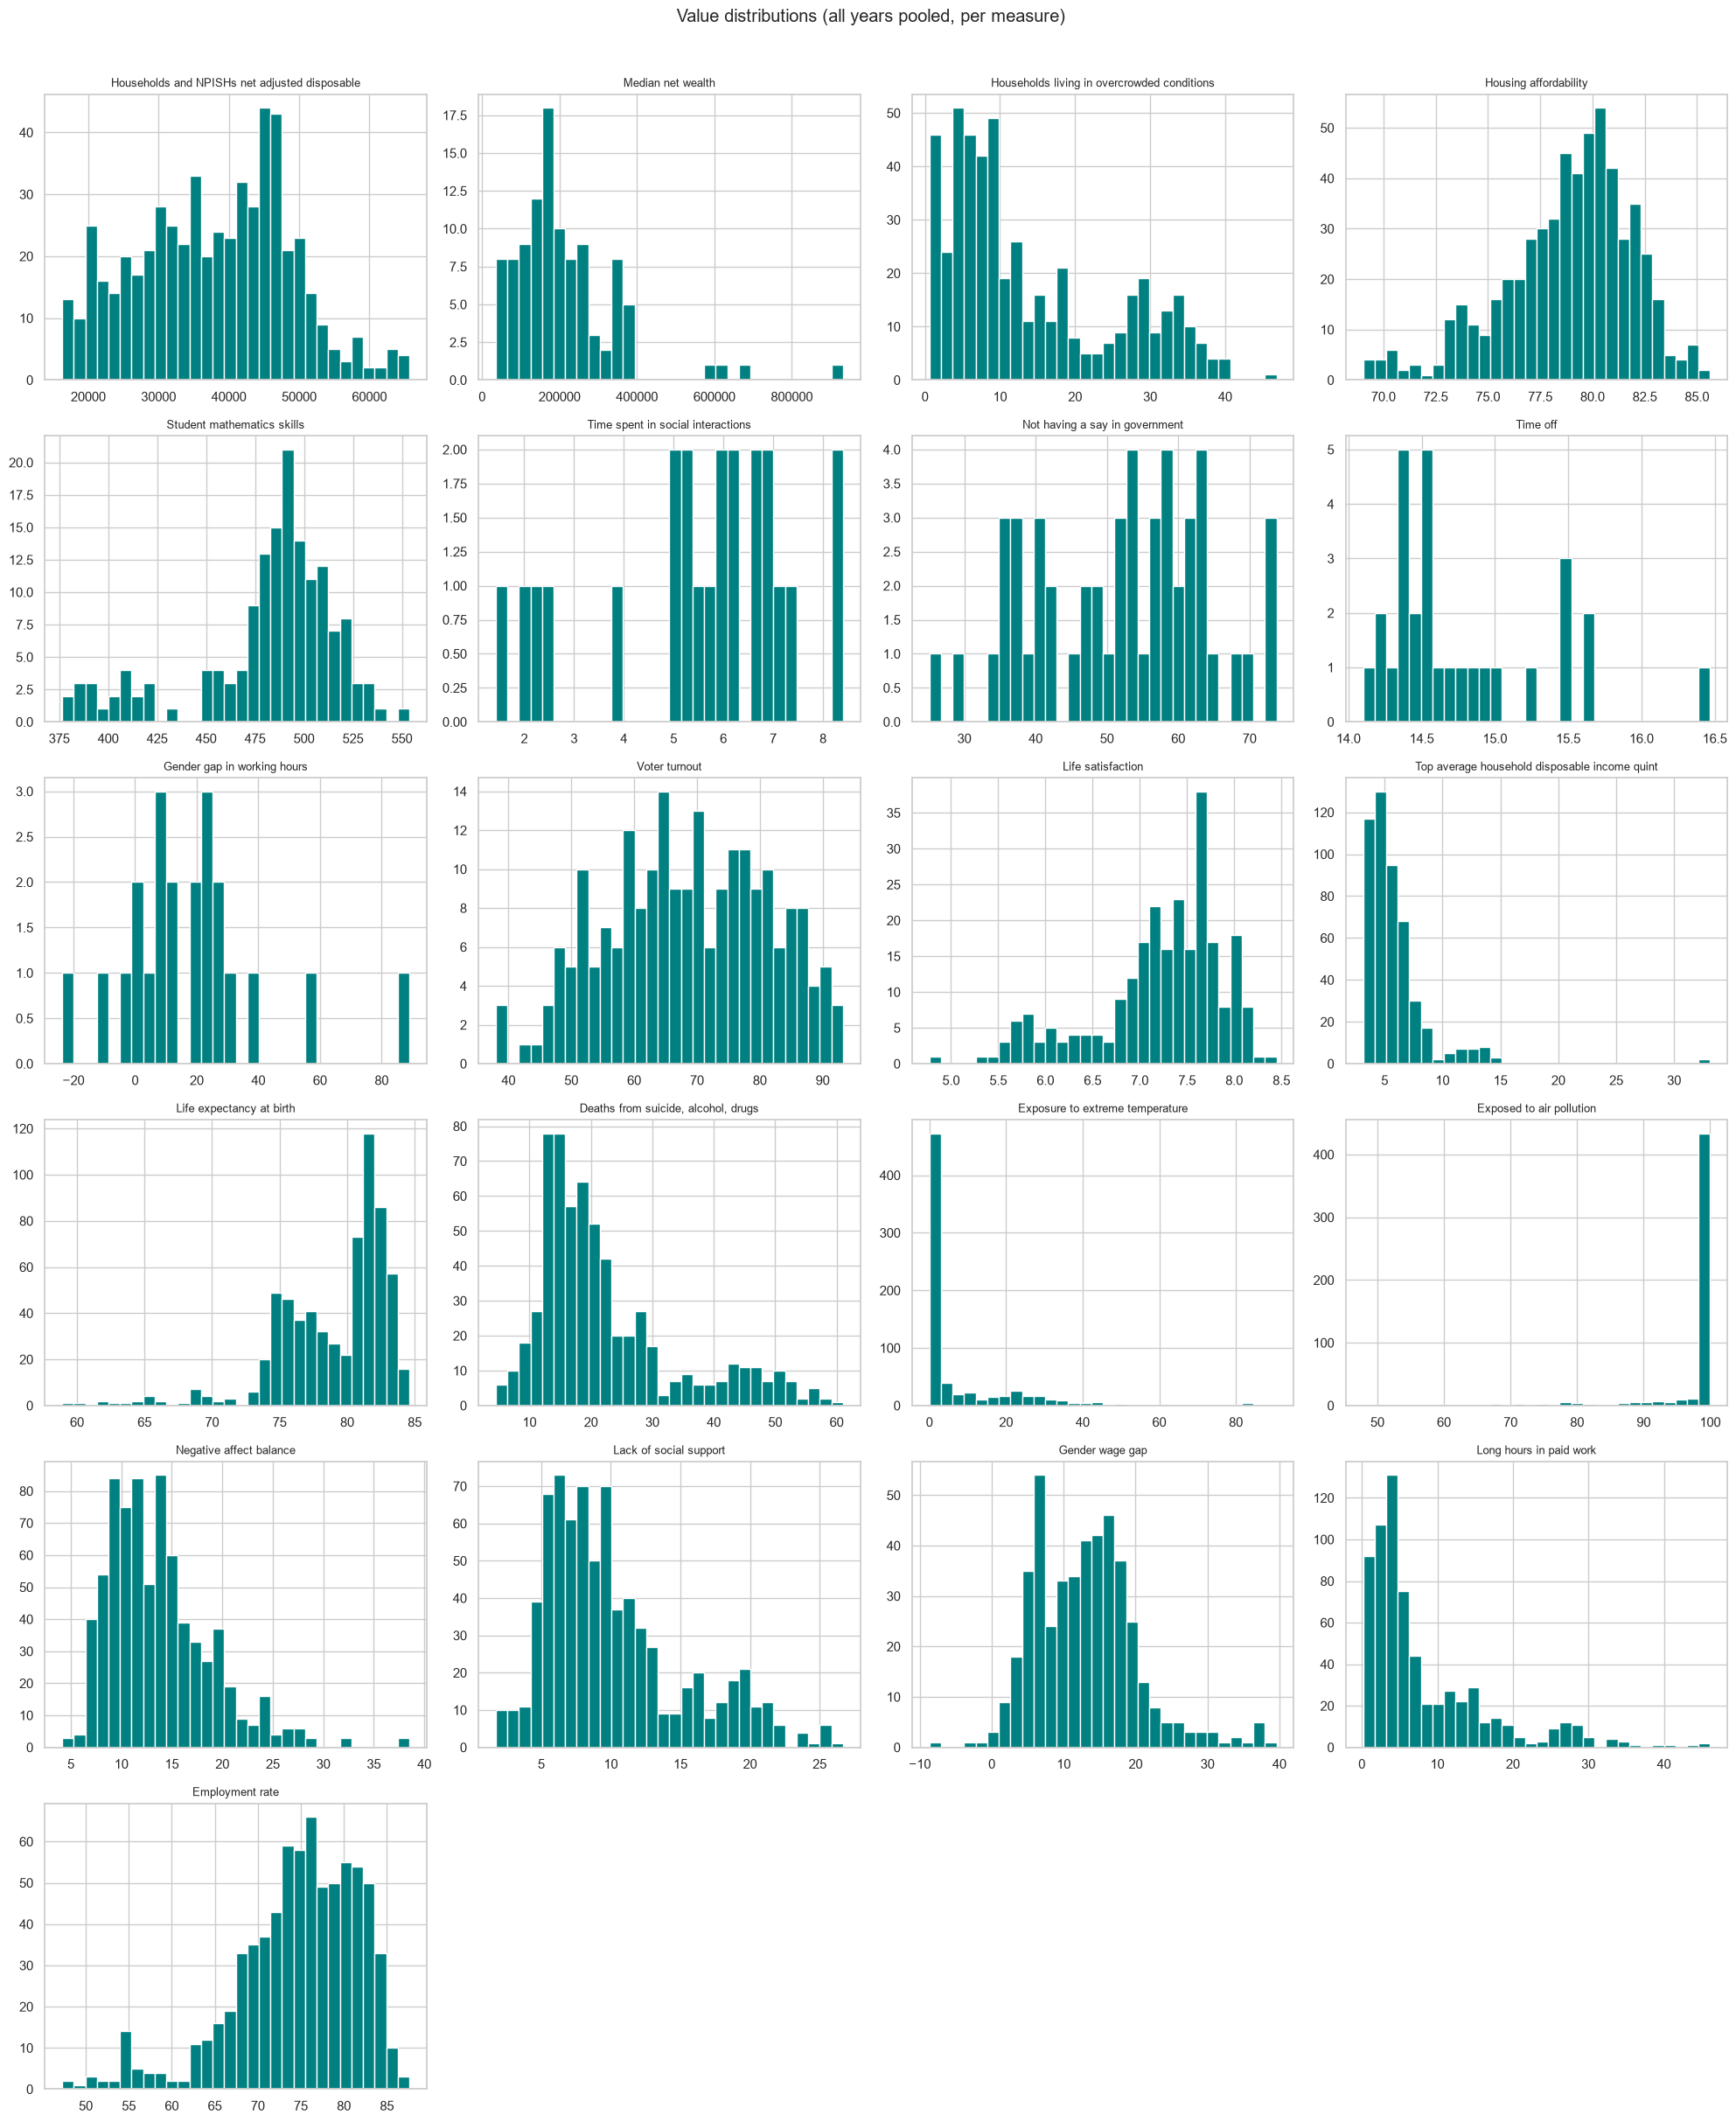

In [15]:
measures = df["measure"].unique()
n = len(measures)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
for ax, m in zip(axes.flat, measures):
    sub = df.loc[df["measure"] == m, "value"]
    ax.hist(sub, bins=30, color="teal", edgecolor="white")
    ax.set_title(m[:45], fontsize=9)
for ax in axes.flat[n:]:
    ax.axis("off")
plt.suptitle("Value distributions (all years pooled, per measure)", y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# Outlier scan: values > 3 SD from the measure mean (z-score within measure)
z = df.assign(z=df.groupby("measure")["value"]
                .transform(lambda s: (s - s.mean()) / s.std()))
outliers = z.loc[z["z"].abs() > 3].sort_values("z", key=abs, ascending=False)
print(f"{len(outliers)} outlier observations (|z| > 3)")
outliers[["country", "measure", "year", "value", "z"]].head(20)

105 outlier observations (|z| > 3)


,country,measure,year,value,z
2724,South Africa,Top average household disposable income quintile,2015,33.117291,9.783443
2725,South Africa,Top average household disposable income quintile,2017,32.444047,9.542400
4389,Finland,Exposed to air pollution,2020,47.847252,-7.847018
4386,Finland,Exposed to air pollution,2017,55.717739,-6.610435
4385,Finland,Exposed to air pollution,2016,57.742588,-6.292297
4186,Thailand,Exposure to extreme temperature,2016,90.619962,5.560884
4194,Thailand,Exposure to extreme temperature,2024,87.147190,5.328422
4180,Thailand,Exposure to extreme temperature,2010,86.688085,5.297690
524,Luxembourg,Median net wealth,2021,932028.000000,5.254925
4193,Thailand,Exposure to extreme temperature,2023,83.983140,5.116624


## 4. Time trends

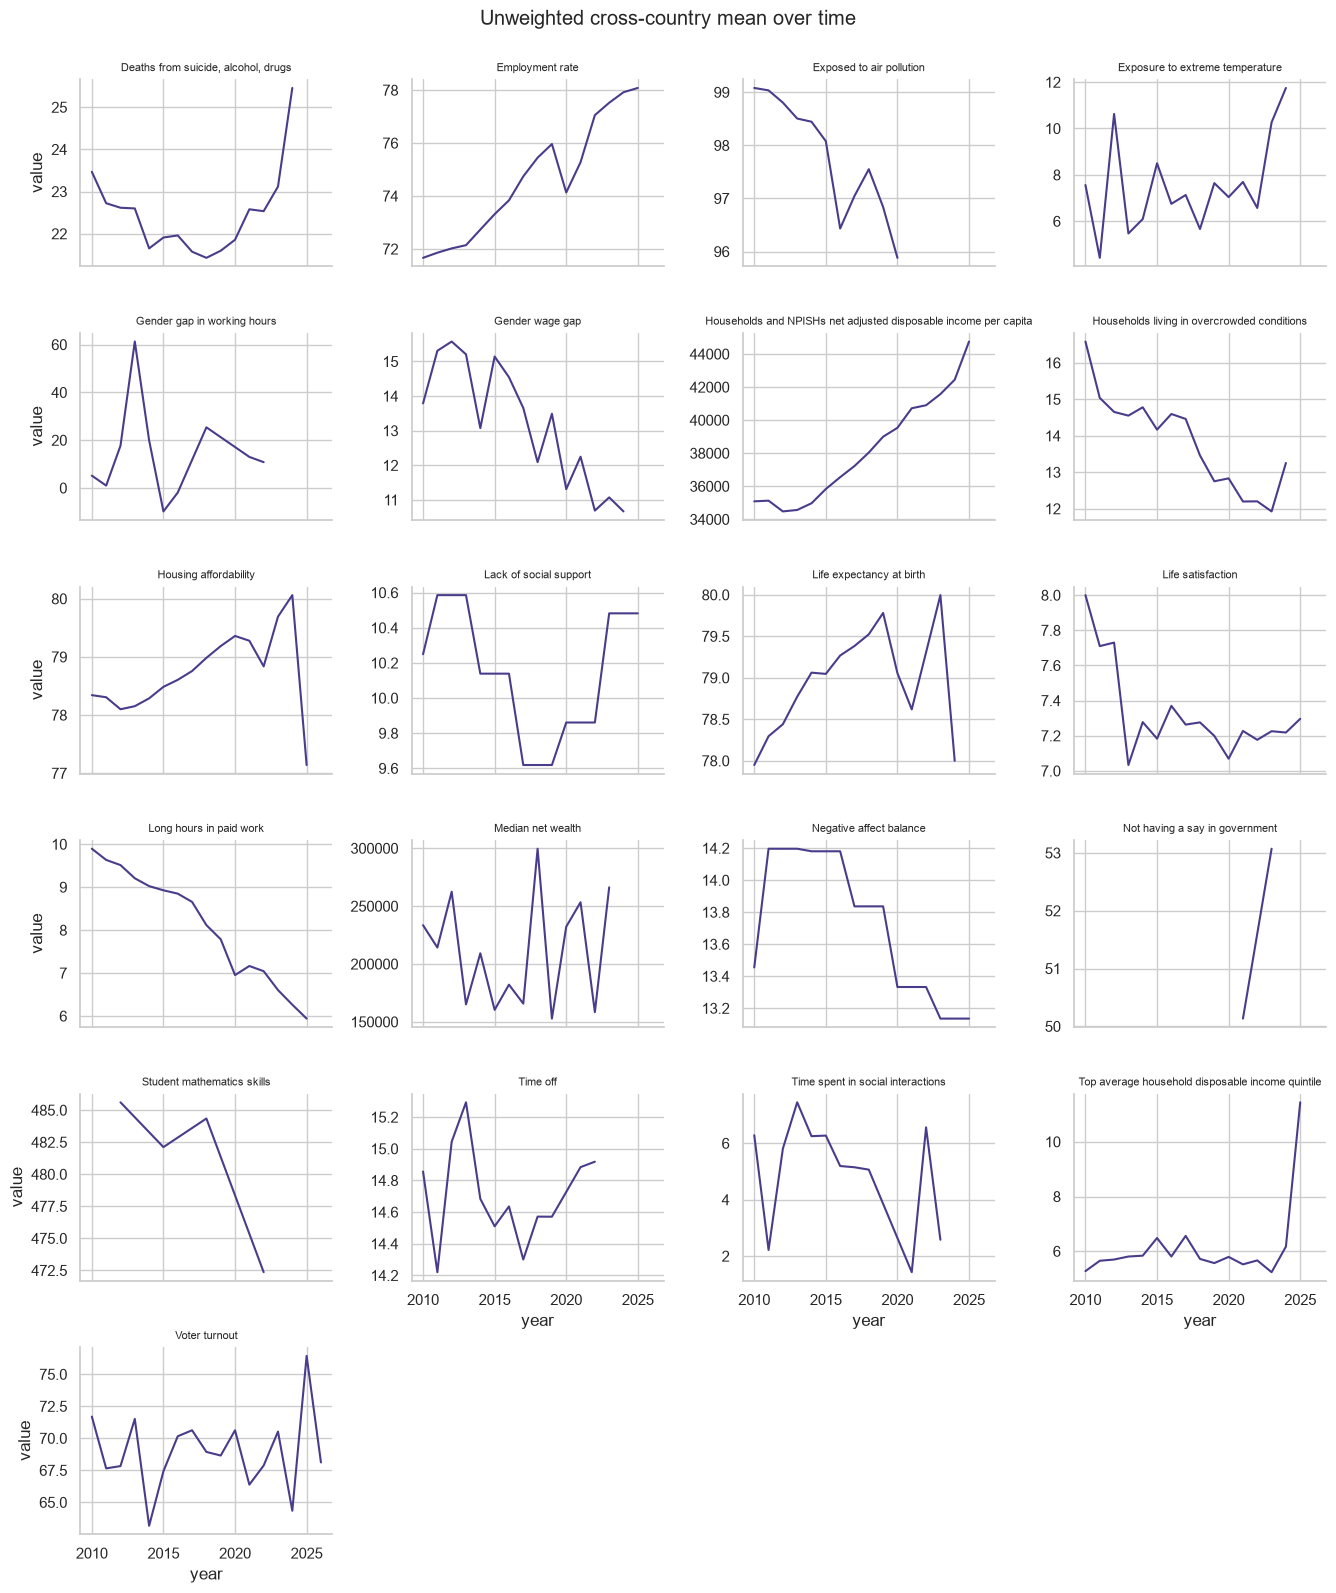

In [17]:
# OECD-wide (unweighted cross-country mean) trend per measure
trend = (df.groupby(["measure", "year"])["value"]
           .mean().reset_index())

g = sns.relplot(data=trend, x="year", y="value", col="measure",
                kind="line", col_wrap=4, facet_kws={"sharey": False},
                height=2.6, aspect=1.3, color="darkslateblue")
g.set_titles("{col_name}", size=8)
g.figure.suptitle("Unweighted cross-country mean over time", y=1.02)
plt.show()

# Caveat: sample composition changes across years (see coverage heatmap),
# so level shifts can reflect country entry/exit rather than real change.

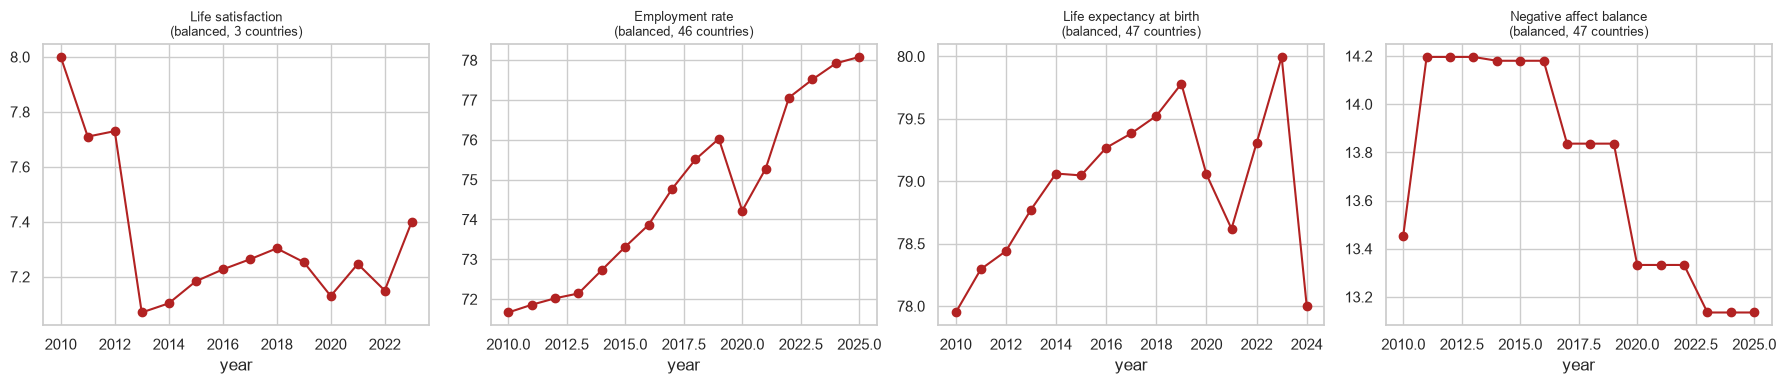

In [18]:
# Composition-stable version for a few key measures: restrict to countries
# present in every year of that measure's span
def balanced_trend(measure, min_years=10):
    sub = df[df["measure"] == measure]
    span = sub.groupby("country")["year"].nunique()
    full = span[span >= min_years].index
    bal = sub[sub["country"].isin(full)]
    return bal.groupby("year")["value"].mean(), len(full)

key = ["Life satisfaction", "Employment rate", "Life expectancy at birth",
       "Negative affect balance"]
fig, axes = plt.subplots(1, len(key), figsize=(18, 4))
for ax, m in zip(axes, key):
    s, k = balanced_trend(m)
    s.plot(ax=ax, marker="o", color="firebrick")
    ax.set_title(f"{m}\n(balanced, {k} countries)", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Latest-year cross-country comparison

In [19]:
# Take each country's most recent observation per measure
latest = (df.sort_values("year")
            .groupby(["country", "measure"], as_index=False)
            .tail(1))
print("Latest-obs year distribution:")
print(latest["year"].value_counts().sort_index())

Latest-obs year distribution:
year
2010      5
2012      9
2013      7
2014     10
2016      5
2017      3
2018      7
2019      5
2020     61
2021     21
2022     88
2023    148
2024    203
2025    224
2026      7
Name: count, dtype: int64


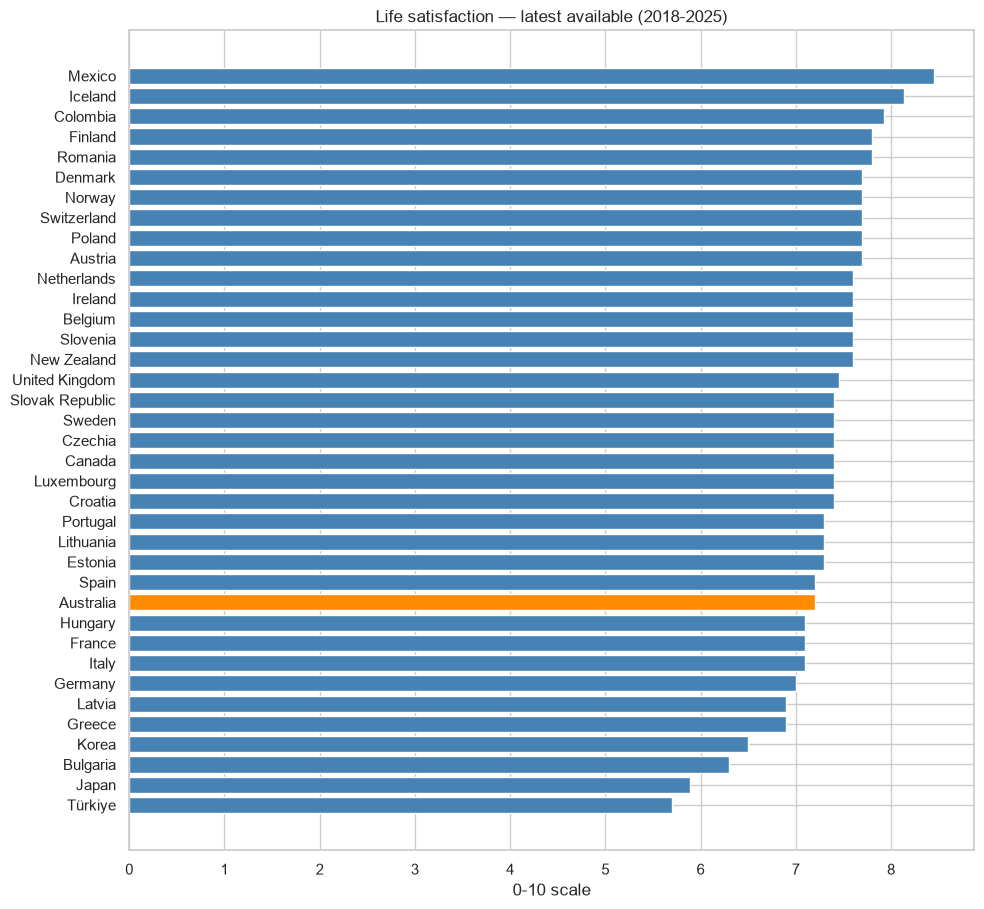

In [20]:
def country_bar(measure, top=None, ascending=False):
    sub = latest[latest["measure"] == measure].sort_values("value", ascending=ascending)
    if top:
        sub = sub.head(top)
    plt.figure(figsize=(10, max(4, 0.25 * len(sub))))
    colors = ["darkorange" if c == "Australia" else "steelblue" for c in sub["country"]]
    plt.barh(sub["country"], sub["value"], color=colors)
    plt.gca().invert_yaxis()
    yr_range = f"{sub['year'].min()}-{sub['year'].max()}"
    plt.title(f"{measure} — latest available ({yr_range})")
    plt.xlabel(sub["unit"].iloc[0])
    plt.tight_layout()
    plt.show()

country_bar("Life satisfaction")

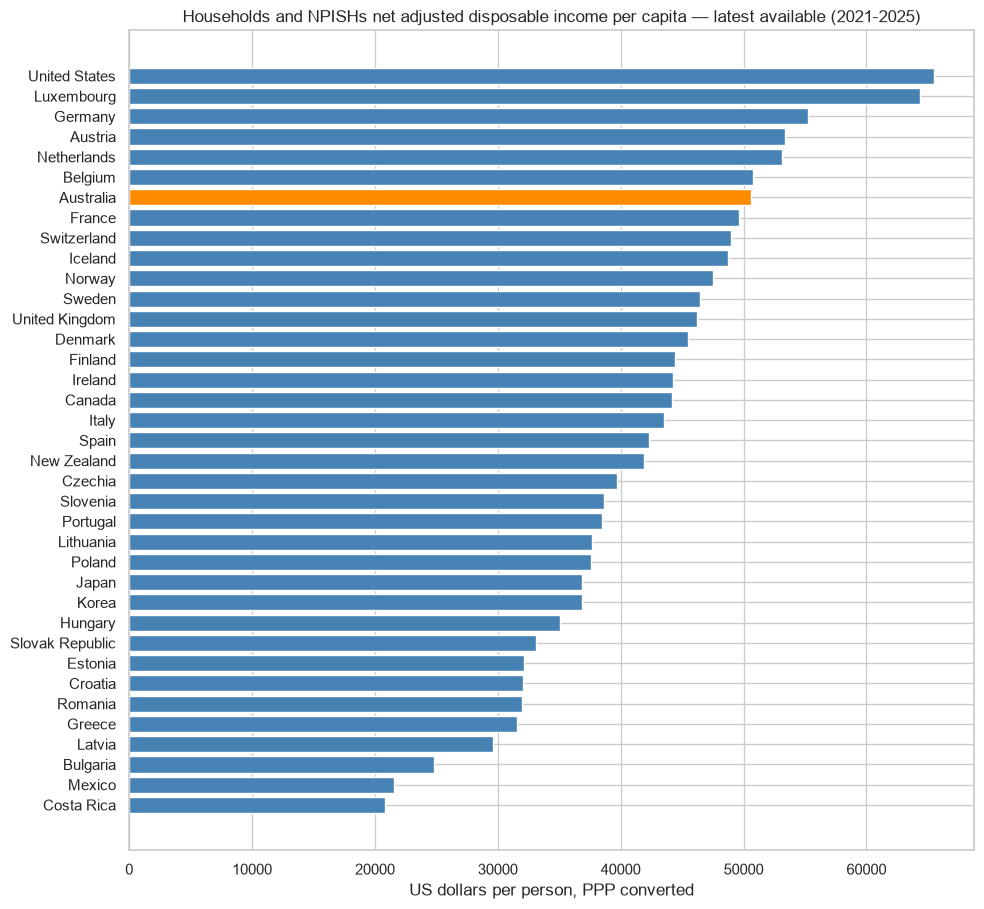

In [21]:
country_bar("Households and NPISHs net adjusted disposable income per capita")

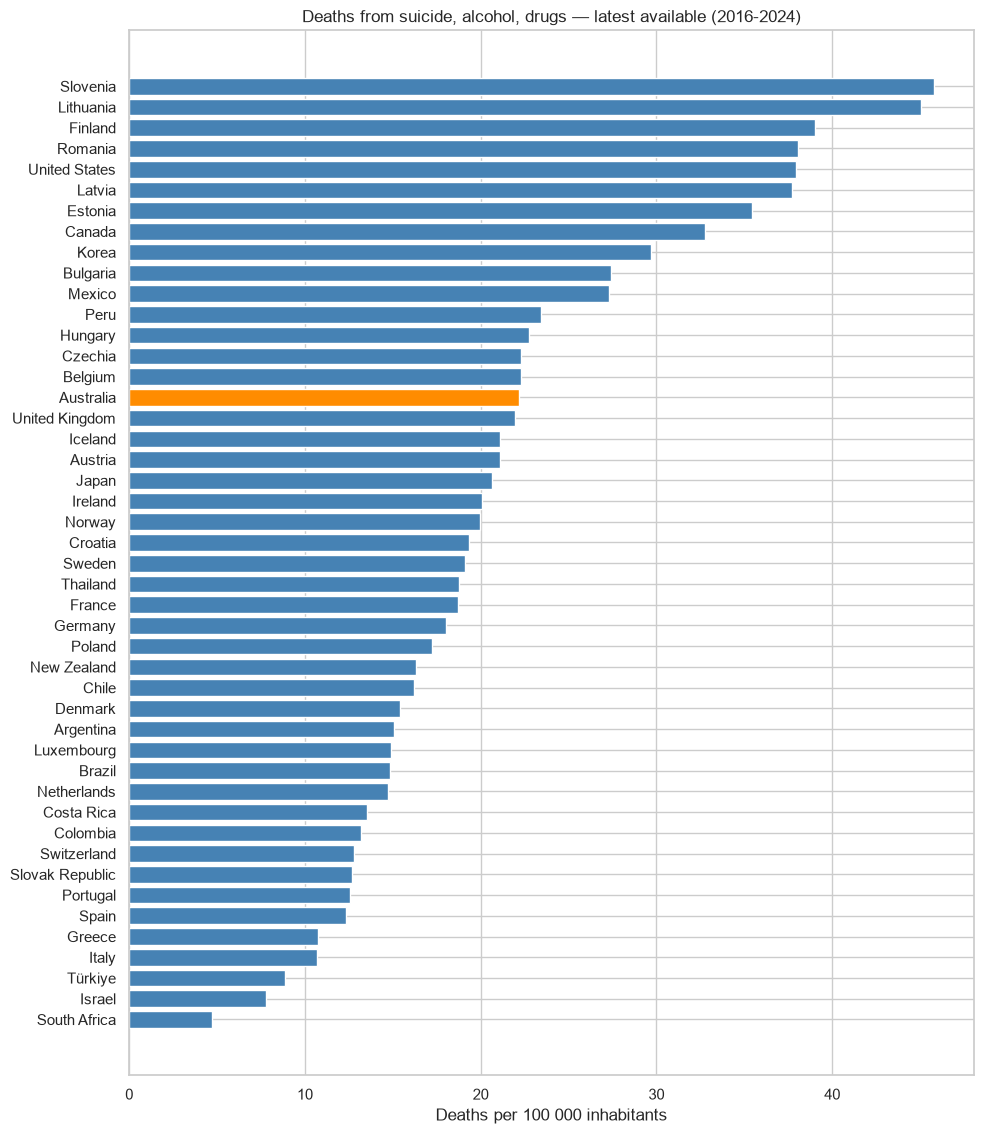

In [22]:
country_bar("Deaths from suicide, alcohol, drugs")

## 6. Wide pivot + correlations between measures

In [23]:
# Wide table: latest value per (country, measure)
wide = latest.pivot(index="country", columns="measure", values="value")
print(wide.shape)
wide.head()

(47, 21)


measure,"Deaths from suicide, alcohol, drugs",Employment rate,Exposed to air pollution,Exposure to extreme temperature,Gender gap in working hours,Gender wage gap,Households and NPISHs net adjusted disposable income per capita,Households living in overcrowded conditions,Housing affordability,Lack of social support,Life expectancy at birth,Life satisfaction,Long hours in paid work,Median net wealth,Negative affect balance,Not having a say in government,Student mathematics skills,Time off,Time spent in social interactions,Top average household disposable income quintile,Voter turnout
country,,,,,,,,,,,,,,,,,,,,,
Argentina,15.074867,77.852,99.873177,24.166210,NaN,9.090909,NaN,NaN,NaN,9.409907,77.4,NaN,15.04,NaN,12.269376,NaN,NaN,NaN,NaN,NaN,77.14
Australia,22.158189,80.427,98.969398,11.189232,NaN,10.671213,50629.0,NaN,80.748138,10.043193,83.0,7.2,9.68,369820.0,14.853043,35.585077,487.080000,NaN,NaN,5.564457,90.67
Austria,21.112609,78.608,99.986313,0.000000,3.544209,11.062252,53375.0,10.710540,80.394714,10.995572,81.9,7.7,4.04,208218.0,9.001008,63.999894,487.270000,15.519680,7.125685,4.450135,76.25
Belgium,22.295484,76.261,99.962547,0.000000,36.600000,0.906909,50771.0,4.161761,81.127060,9.247652,82.5,7.6,3.81,375999.0,13.328755,53.506014,489.490000,15.516667,5.950000,3.611836,87.42
Brazil,14.819148,71.813,99.903893,29.231784,NaN,10.000000,NaN,NaN,NaN,13.664929,75.8,NaN,6.26,NaN,15.548109,NaN,383.569124,NaN,NaN,11.236409,79.42


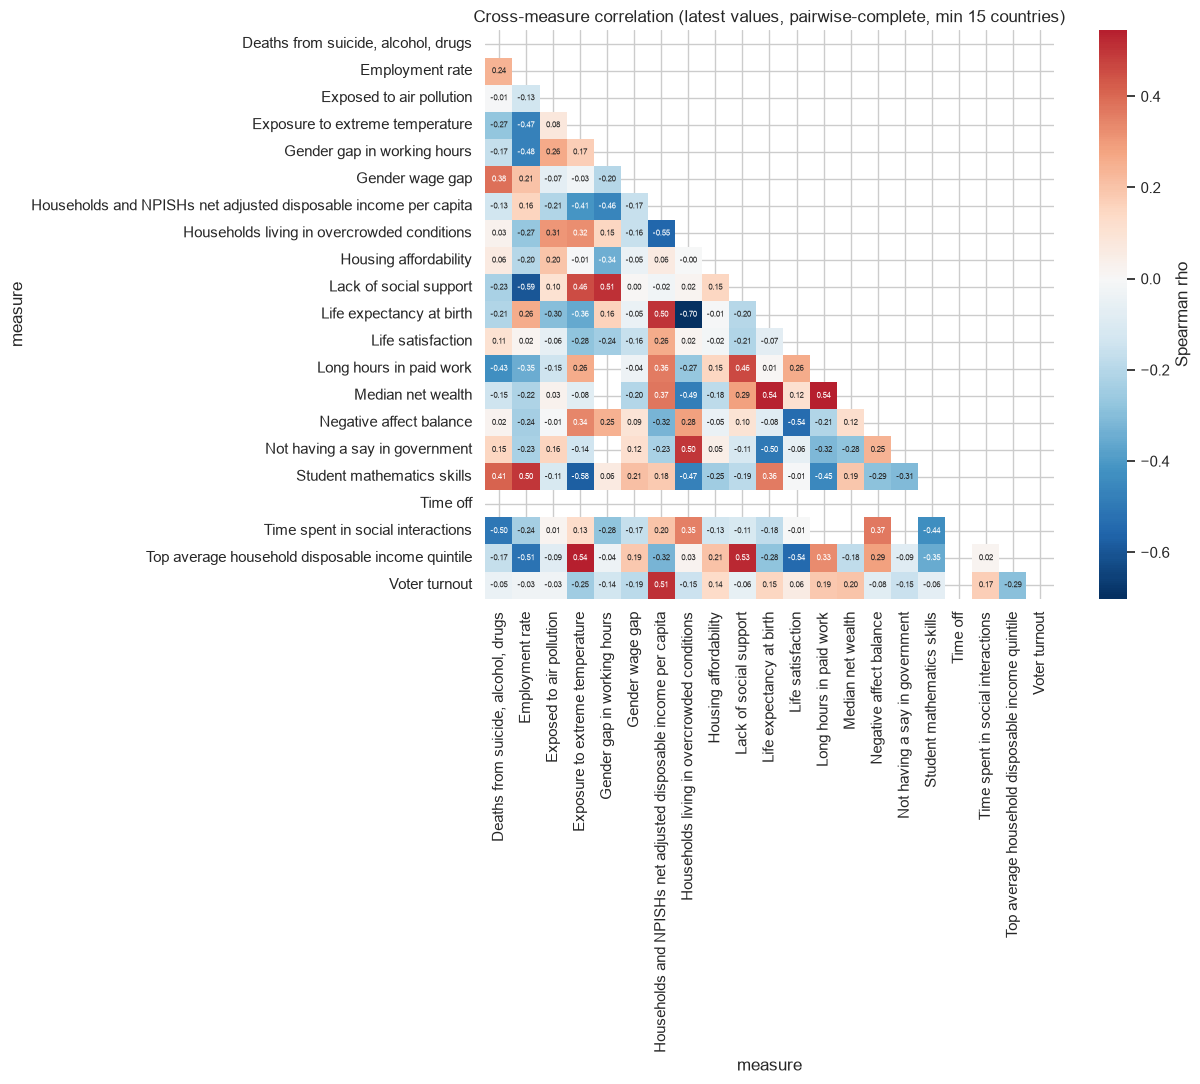

In [24]:
# Pairwise-complete Spearman correlation (robust to different scales/units)
corr = wide.corr(method="spearman", min_periods=15)

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 6}, square=True,
            cbar_kws={"label": "Spearman rho"})
plt.title("Cross-measure correlation (latest values, pairwise-complete, min 15 countries)")
plt.tight_layout()
plt.show()

In [26]:
# Strongest relationships
corr_copy = corr.copy()
corr_copy.index.name = "m1"
corr_copy.columns.name = "m2"
pairs = (corr_copy.where(~mask).stack()
                  .rename("rho")
                  .reset_index())
pairs.reindex(pairs["rho"].abs().sort_values(ascending=False).index).head(15)

,m1,m2,rho
217,Life expectancy at birth,Households living in overcrowded conditions,-0.701626
190,Lack of social support,Employment rate,-0.594935
339,Student mathematics skills,Exposure to extreme temperature,-0.578119
153,Households living in overcrowded conditions,Households and NPISHs net adjusted disposable ...,-0.551261
285,Median net wealth,Long hours in paid work,0.544335
410,Top average household disposable income quintile,Life satisfaction,-0.543428
402,Top average household disposable income quintile,Exposure to extreme temperature,0.539987
283,Median net wealth,Life expectancy at birth,0.537732
305,Negative affect balance,Life satisfaction,-0.537598
408,Top average household disposable income quintile,Lack of social support,0.525322


## 7. Australia deep-dive vs OECD distribution

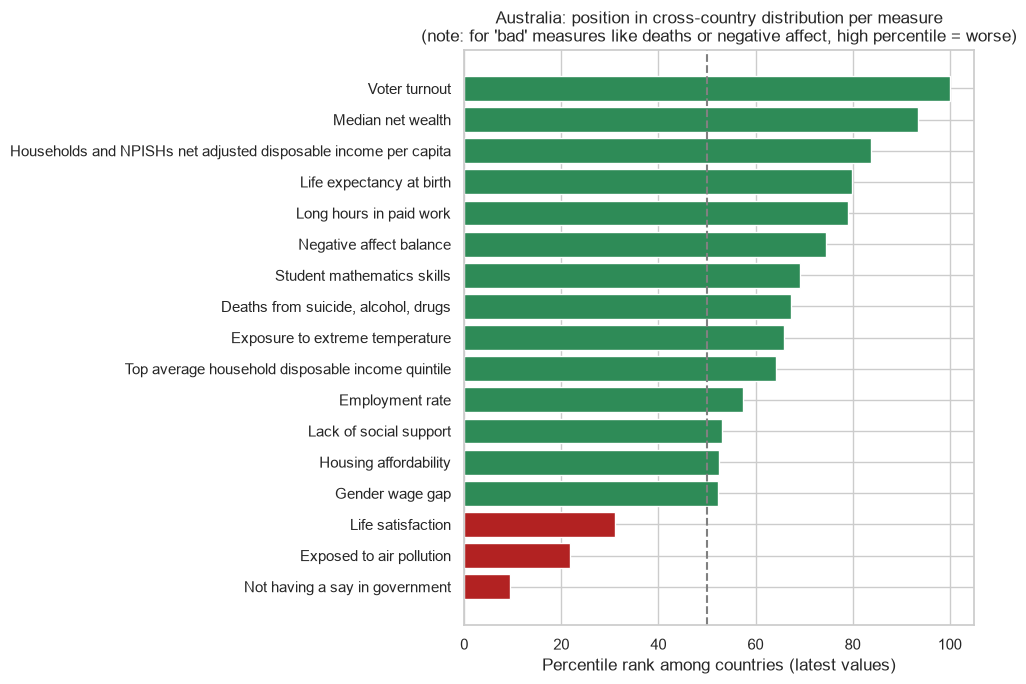

In [27]:
FOCUS = "Australia"
aus = latest[latest["country"] == FOCUS].set_index("measure")["value"]

# Where does the focus country sit in the cross-country distribution? (percentile rank)
pct = wide.rank(pct=True).loc[FOCUS].dropna().sort_values()

plt.figure(figsize=(10, 7))
colors = ["firebrick" if p < 0.5 else "seagreen" for p in pct]
plt.barh(pct.index, pct * 100, color=colors)
plt.axvline(50, color="grey", ls="--")
plt.xlabel("Percentile rank among countries (latest values)")
plt.title(f"{FOCUS}: position in cross-country distribution per measure\n"
          "(note: for 'bad' measures like deaths or negative affect, high percentile = worse)")
plt.tight_layout()
plt.show()

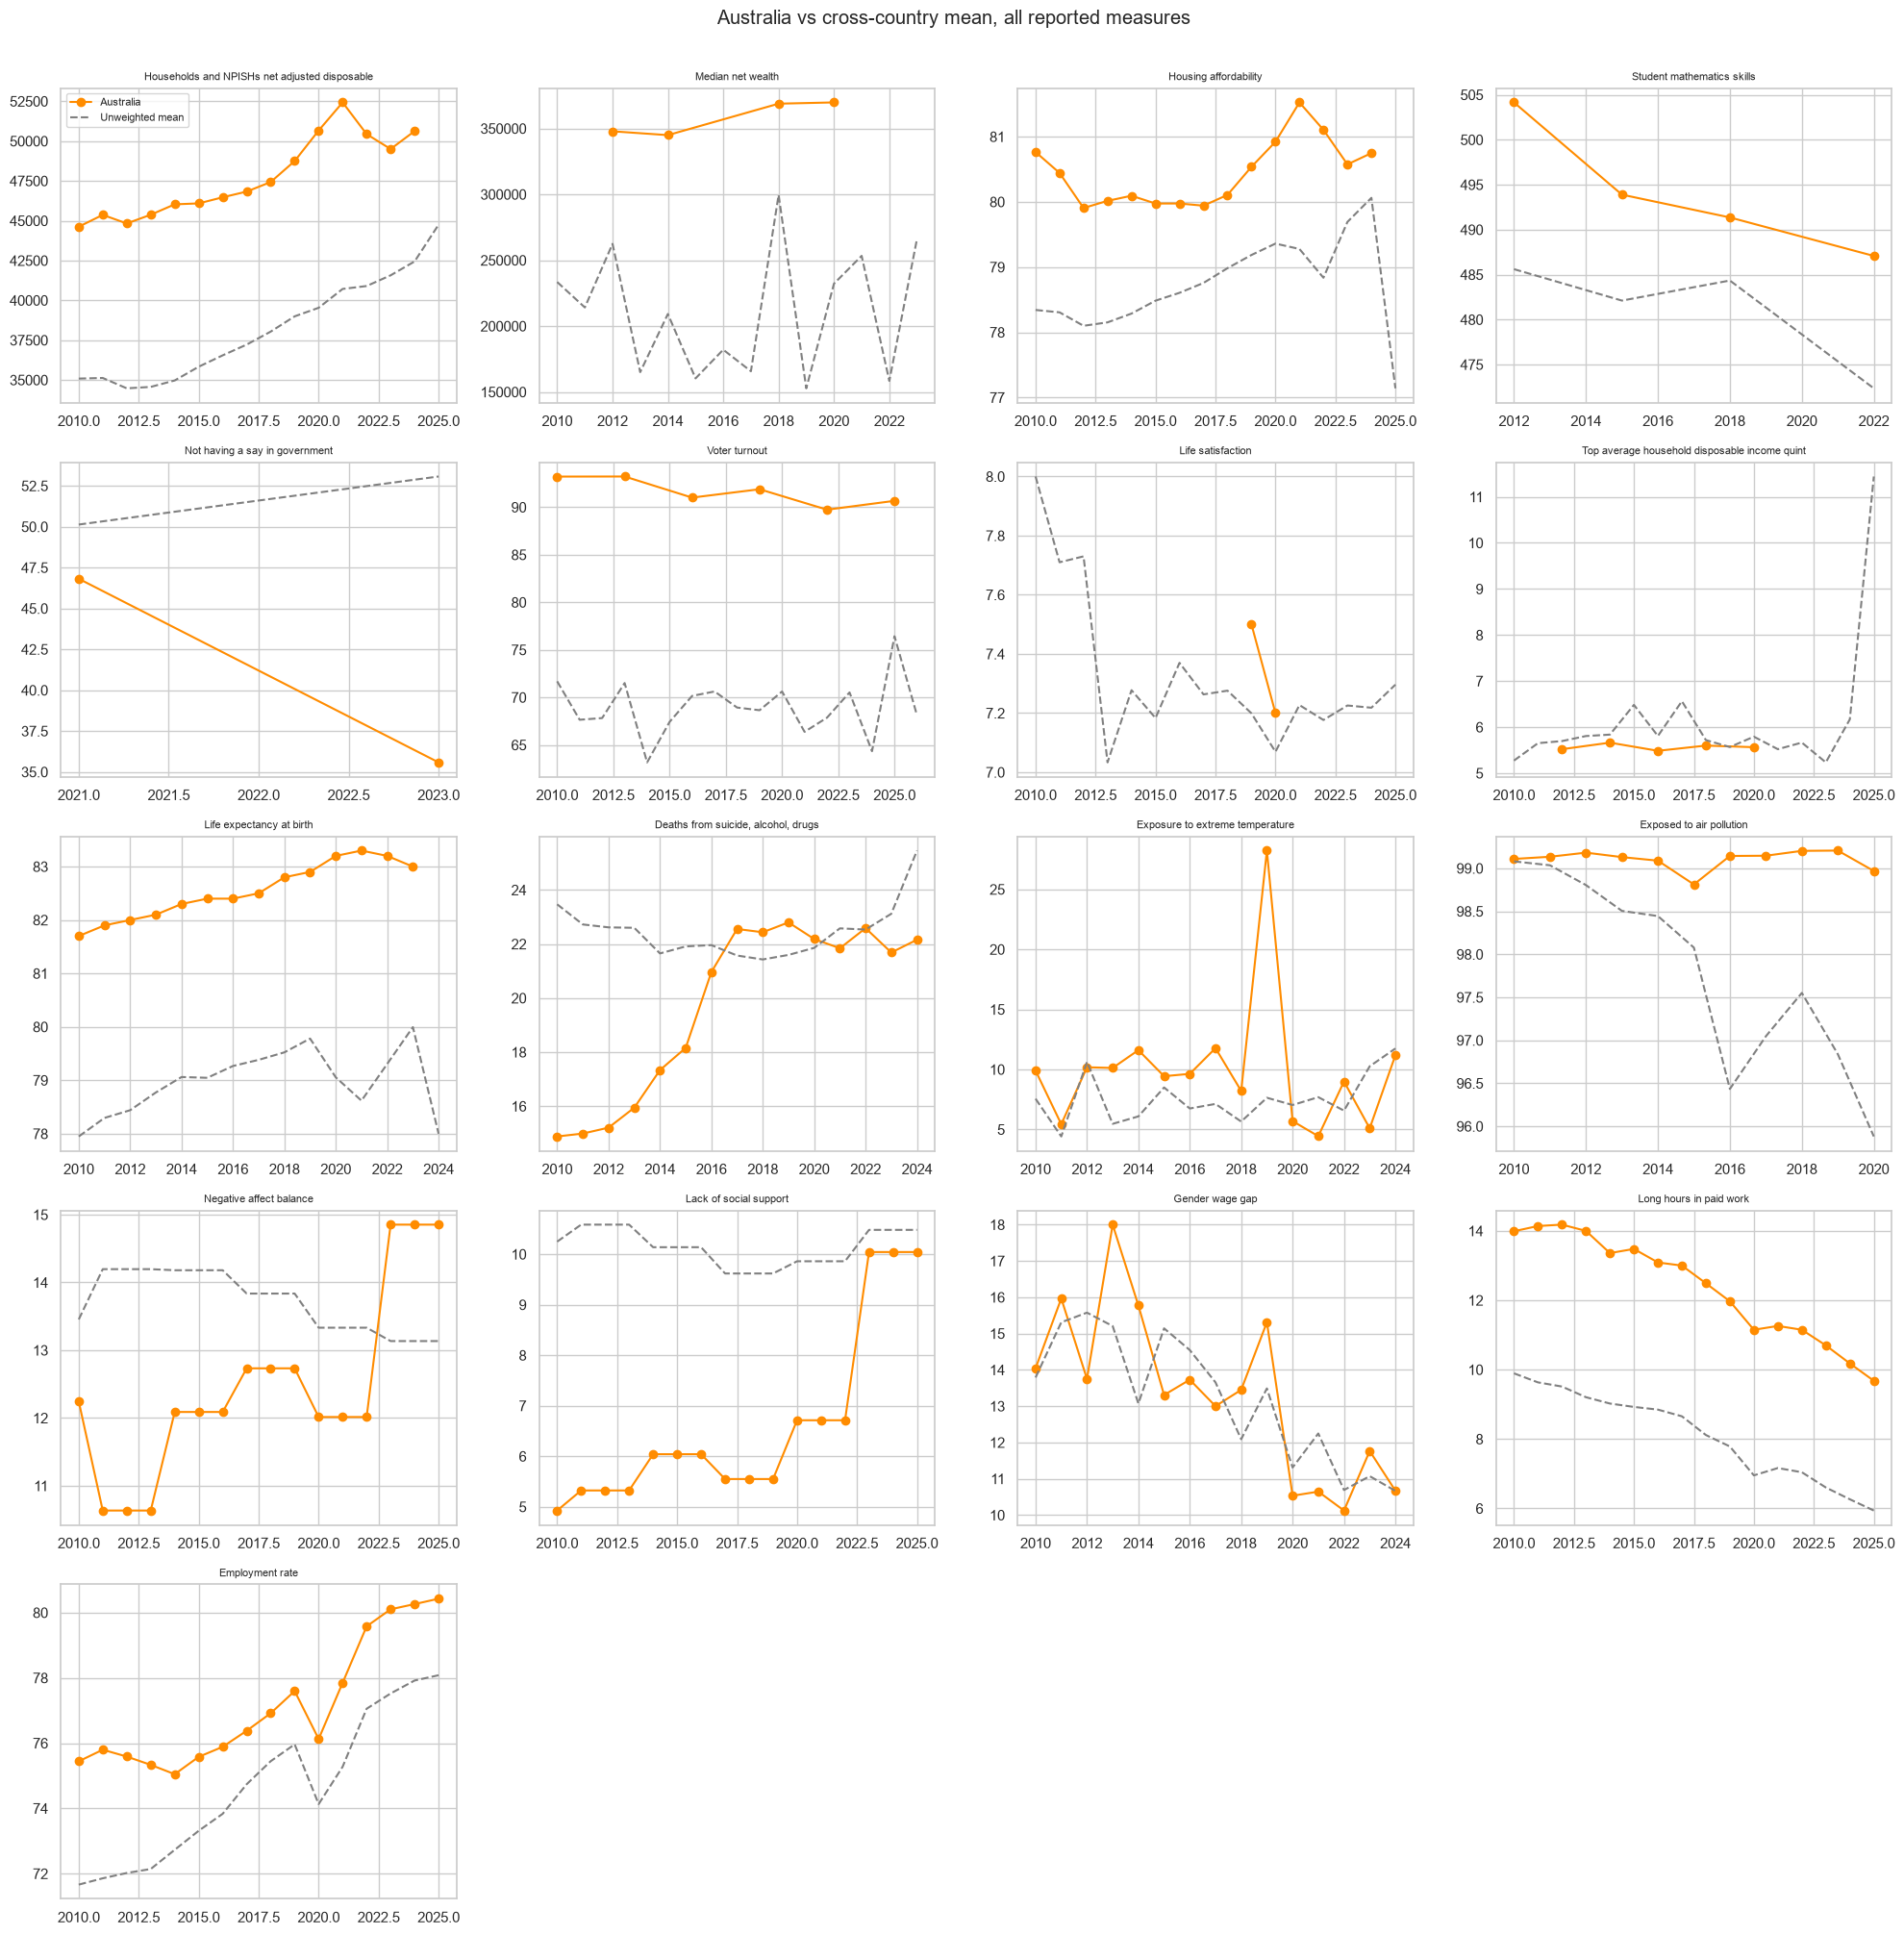

In [28]:
# Trajectory vs OECD unweighted mean for all measures Australia reports
aus_ts = df[df["country"] == FOCUS]
oecd_ts = df.groupby(["measure", "year"])["value"].mean().rename("oecd_mean")

ms = aus_ts["measure"].unique()
ncols = 4
nrows = int(np.ceil(len(ms) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
for ax, m in zip(axes.flat, ms):
    a = aus_ts[aus_ts["measure"] == m].set_index("year")["value"].sort_index()
    o = oecd_ts.loc[m]
    ax.plot(a.index, a.values, marker="o", color="darkorange", label=FOCUS)
    ax.plot(o.index, o.values, ls="--", color="grey", label="Unweighted mean")
    ax.set_title(m[:45], fontsize=8)
for ax in axes.flat[len(ms):]:
    ax.axis("off")
axes.flat[0].legend(fontsize=8)
plt.suptitle(f"{FOCUS} vs cross-country mean, all reported measures", y=1.005)
plt.tight_layout()
plt.show()